# RSD multipoles with SCOPE + Kaiser model validation

Uses the new `compute_xi_smu` function in SCOPE to measure ξ(s, μ) → ξ₀(s), ξ₂(s),
then overlays the linear-theory Kaiser prediction to validate the subvolume correction.

**Kaiser model** (Hamilton 1992, plane-parallel, distant-observer):
$$\xi_0(s) = \left(1 + \frac{2\beta}{3} + \frac{\beta^2}{5}\right) \xi(r)$$
$$\xi_2(s) = \left(\frac{4\beta}{3} + \frac{4\beta^2}{7}\right) \left[\xi(r) - \bar{\xi}(r)\right]$$
where $\beta = f/b$, $f = \Omega_m(z)^{0.55}$, and $\bar{\xi}(r) = \frac{3}{r^3}\int_0^r \xi(r')r'^2 dr'$.

In [ ]:
import sys
from pathlib import Path

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import interp1d
from scipy.optimize import minimize_scalar

SCOPE_PATH = "/cosma/apps/durham/dc-hick2/SCOPE/python"
PROJECT_ROOT = Path("../..").resolve()
if SCOPE_PATH not in sys.path:
    sys.path.insert(0, SCOPE_PATH)
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

import scope
from config import Cosmology, get_snapshot_redshift
from utils.read_galaxies import read_galaxy_arrays


from utils.matplotlib_config import register_matplotlib_setconfig
register_matplotlib_setconfig(mpl)
mpl.setconfig()

plt.rcParams['figure.figsize'] = (8, 6)
plt.rcParams['font.size'] = 11

## Parameters

In [2]:
IZ         = 271
SIM        = "L800"
MODEL      = "lc16"
BOXSIZE    = 542.16      # Mpc/h
K_TOTAL    = 1024        # total realisations
N_SUBVOLS  = 32          # realisations to load (increase for better stats)
MHALO_MIN  = 1e10        # M_sun/h
SEED       = 42

BASE_DIR = Path(f"/cosma5/data/durham/dc-hick2/Galform_Out/{SIM}/{MODEL}")

# Bin edges
R_BINS = np.logspace(np.log10(0.5), np.log10(100.0), 31)   # real space
S_BINS = np.logspace(np.log10(0.5), np.log10(80.0),  26)   # redshift space
N_MU_BINS = 100

# Kaiser fit scale range (Mpc/h)
FIT_SMIN, FIT_SMAX = 8.0, 60.0

print(f"iz={IZ}  n_subvols={N_SUBVOLS}/{K_TOTAL}")

iz=271  n_subvols=32/1024


In [3]:
print("Loading galaxy data...")

Loading galaxy data...


## Load galaxies and apply RSD shift

In [4]:
z_snap = get_snapshot_redshift(f"iz{IZ}")
h      = Cosmology.h
om     = Cosmology.OMEGA_M
ol     = Cosmology.OMEGA_L
ez     = np.sqrt(om * (1.0 + z_snap)**3 + ol)
hz     = 100.0 * h * ez   # H(z) in km/s/Mpc

print(f"z = {z_snap:.4f},  H(z) = {hz:.2f} km/s/Mpc,  f(z) = {(om*(1+z_snap)**3/ez**2)**0.55:.4f}")

# Select N_SUBVOLS random ivols
rng    = np.random.default_rng(SEED)
all_ivols = list(range(K_TOTAL))
ivols  = sorted(rng.choice(all_ivols, size=N_SUBVOLS, replace=False).tolist())

pos_real_chunks, pos_rsd_chunks, sv_chunks = [], [], []

iz_path = BASE_DIR / f"iz{IZ}"
for label, iv in enumerate(ivols):
    arr, meta = read_galaxy_arrays(
        iz_path,
        ivol=iv,
        mhalo_min=MHALO_MIN,
        fields=["vzgal"],
        include_positions=True,
    )
    x  = np.asarray(arr["x"],     dtype=np.float64)
    y  = np.asarray(arr["y"],     dtype=np.float64)
    z  = np.asarray(arr["z"],     dtype=np.float64)
    vz = np.asarray(arr["vzgal"], dtype=np.float64)

    # RSD displacement in Mpc/h
    ds   = (vz / hz) * h
    z_rsd = np.mod(z + ds, BOXSIZE)

    sv = np.full(len(x), label, dtype=np.int32)
    pos_real_chunks.append(np.column_stack([x, y, z]))
    pos_rsd_chunks.append(np.column_stack([x, y, z_rsd]))
    sv_chunks.append(sv)

coords_real = np.vstack(pos_real_chunks)
coords_rsd  = np.vstack(pos_rsd_chunks)
subvol_ids  = np.concatenate(sv_chunks)

print(f"Total galaxies loaded: {len(coords_real):,}")

z = 0.0000,  H(z) = 67.77 km/s/Mpc,  f(z) = 0.5223
Total galaxies loaded: 1,034,900


## Real-space ξ(r) with SCOPE

In [5]:
res_xi = scope.compute_xi(
    coords_real, subvol_ids, R_BINS, BOXSIZE, K_TOTAL, N_SUBVOLS
)
r_mid = res_xi["r_mid"]
xi_r  = res_xi["xi"]
print("Real-space ξ(r) done")

Real-space ξ(r) done


## Redshift-space ξ(s, μ) with SCOPE

In [6]:
res_smu = scope.compute_xi_smu(
    coords_rsd, subvol_ids, S_BINS, BOXSIZE, K_TOTAL, N_SUBVOLS,
    n_mu_bins=N_MU_BINS, mu_max=1.0,
)
s_mid  = res_smu["s_mid"]
mu_mid = res_smu["mu_mid"]
xi_smu = res_smu["xi_smu"]
xi0    = res_smu["xi0"]
xi2    = res_smu["xi2"]
print("RSD ξ(s, μ) done")

RSD ξ(s, μ) done


## Null test: quadrupole vanishes in real space

Running `compute_xi_smu` on the *real-space* positions (no RSD shift) should give ξ₂ ≈ 0 everywhere — there is no preferred direction — and ξ₀ should recover the 1-D ξ(r) from `compute_xi`.
Any non-zero quadrupole here indicates a bug in the Legendre projection or a broken periodic boundary condition, not a physical signal.

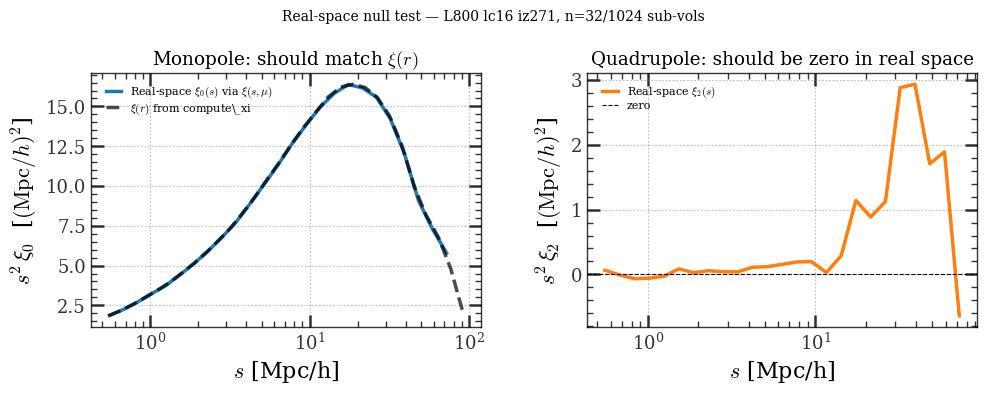

Null test done.


In [7]:
res_real_smu = scope.compute_xi_smu(
    coords_real, subvol_ids, S_BINS, BOXSIZE, K_TOTAL, N_SUBVOLS,
    n_mu_bins=N_MU_BINS, mu_max=1.0,
)
xi0_real = res_real_smu["xi0"]
xi2_real = res_real_smu["xi2"]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ax = axes[0]
ax.plot(s_mid, s_mid**2 * xi0_real, color="C0",
        label=r"Real-space $\xi_0(s)$ via $\xi(s,\mu)$")
ax.plot(r_mid, r_mid**2 * xi_r, color="k", ls="--", alpha=0.7,
        label=r"$\xi(r)$ from compute\_xi")
ax.set_xscale("log")
ax.set_xlabel(r"$s$ [Mpc/h]")
ax.set_ylabel(r"$s^2\,\xi_0$  [$(\mathrm{Mpc}/h)^2$]")
ax.set_title(r"Monopole: should match $\xi(r)$")
ax.legend(fontsize=8)

ax = axes[1]
ax.plot(s_mid, s_mid**2 * xi2_real, color="C1",
        label=r"Real-space $\xi_2(s)$")
ax.axhline(0, color="k", lw=0.8, ls="--", label="zero")
ax.set_xscale("log")
ax.set_xlabel(r"$s$ [Mpc/h]")
ax.set_ylabel(r"$s^2\,\xi_2$  [$(\mathrm{Mpc}/h)^2$]")
ax.set_title(r"Quadrupole: should be zero in real space")
ax.legend(fontsize=8)

fig.suptitle(
    f"Real-space null test — L800 lc16 iz{IZ}, n={N_SUBVOLS}/{K_TOTAL} sub-vols",
    fontsize=10,
)
fig.tight_layout()
out_dir = Path("_plots/scope_rsd_kaiser")
out_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(out_dir / f"null_test_real_space_iz{IZ}_n{N_SUBVOLS}.png", dpi=150)
plt.show()
print("Null test done.")

## Naive estimator: raw pair counts with no subvolume correction

The naive approach treats all pairs equally — α=β=1, so DD_naive = DD_auto + DD_cross with no reweighting.  The RR is still computed for the selected catalogue density.

Because each ivol keeps all galaxies within a halo together, loading m ivols gives you the **full** 1-halo signal from those m/k halos.  But RR scales as N² ∝ (m/k)², so the 1-halo term in ξ is boosted by (m/k)/(m/k)² = k/m ≈ 1024/<n> — a factor of ~32 at n=32.  The 2-halo (large-scale) term is also affected because β≠1 would be needed to correctly weight cross-ivol pairs.

Expected 1-halo boost factor k/m = 1024/32 = 32.0x


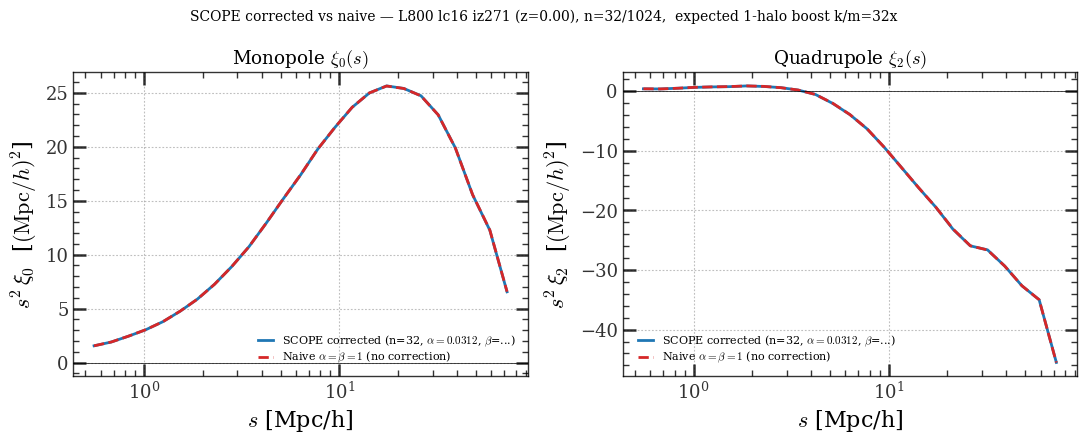

In [8]:
# Naive: alpha=beta=1, no subvolume correction
# DD_naive = DD_auto + DD_cross, divided by the same RR as the corrected estimator
_dmu_n    = 1.0 / N_MU_BINS
_mu_mid_n = np.linspace(_dmu_n / 2.0, 1.0 - _dmu_n / 2.0, N_MU_BINS)
_L2_n     = 0.5 * (3.0 * _mu_mid_n**2 - 1.0)

xi_smu_naive = (res_smu["dd_auto"] + res_smu["dd_cross"]) / res_smu["rr"] - 1.0
xi0_naive    = np.nansum(xi_smu_naive * _dmu_n,                        axis=1)
xi2_naive    = 5.0 * np.nansum(xi_smu_naive * _L2_n[np.newaxis, :] * _dmu_n, axis=1)

boost = K_TOTAL / N_SUBVOLS
print(f"Expected 1-halo boost factor k/m = {K_TOTAL}/{N_SUBVOLS} = {boost:.1f}x")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, xi_corr, xi_nav, ylabel, title in zip(
    axes,
    [xi0,       xi2],
    [xi0_naive, xi2_naive],
    [r"$s^2\,\xi_0$  [$(\mathrm{Mpc}/h)^2$]",
     r"$s^2\,\xi_2$  [$(\mathrm{Mpc}/h)^2$]"],
    ["Monopole $\\xi_0(s)$", "Quadrupole $\\xi_2(s)$"],
):
    ax.plot(s_mid, s_mid**2 * xi_corr, color="C0", lw=2,
            label=rf"SCOPE corrected (n={N_SUBVOLS}, $\alpha={N_SUBVOLS/K_TOTAL:.4f}$, $\beta$=...)")
    ax.plot(s_mid, s_mid**2 * xi_nav,  color="C3", lw=2, ls="--",
            label=r"Naive $\alpha=\beta=1$ (no correction)")
    ax.axhline(0, color="k", lw=0.5)
    ax.set_xscale("log")
    ax.set_xlabel(r"$s$ [Mpc/h]")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(fontsize=8)

fig.suptitle(
    f"SCOPE corrected vs naive — L800 lc16 iz{IZ} (z={z_snap:.2f}), "
    f"n={N_SUBVOLS}/{K_TOTAL},  expected 1-halo boost k/m={boost:.0f}x",
    fontsize=10,
)
fig.tight_layout()
out_dir = Path("_plots/scope_rsd_kaiser")
out_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(out_dir / f"naive_vs_corrected_iz{IZ}_n{N_SUBVOLS}.png", dpi=150)
plt.show()

## Why n=32 looks fine: demonstrating the correction at low n

At n=32 the correction factors are tiny (β≈1.03, auto pairs are 3% of all pairs) so naive and corrected look almost identical.  Dropping to n=2 makes the difference catastrophic:

| n | α | β | auto fraction |
|---|---|---|---|
| 2  | 0.002 | **1.998** | 50% |
| 4  | 0.004 | 1.332 | 25% |
| 32 | 0.031 | 1.031 | 3%  |

At n=2, the naive estimator nearly **doubles** every cross pair (β≈2) and auto pairs are half of all pairs — the 1-halo boost is 512× uncorrected.

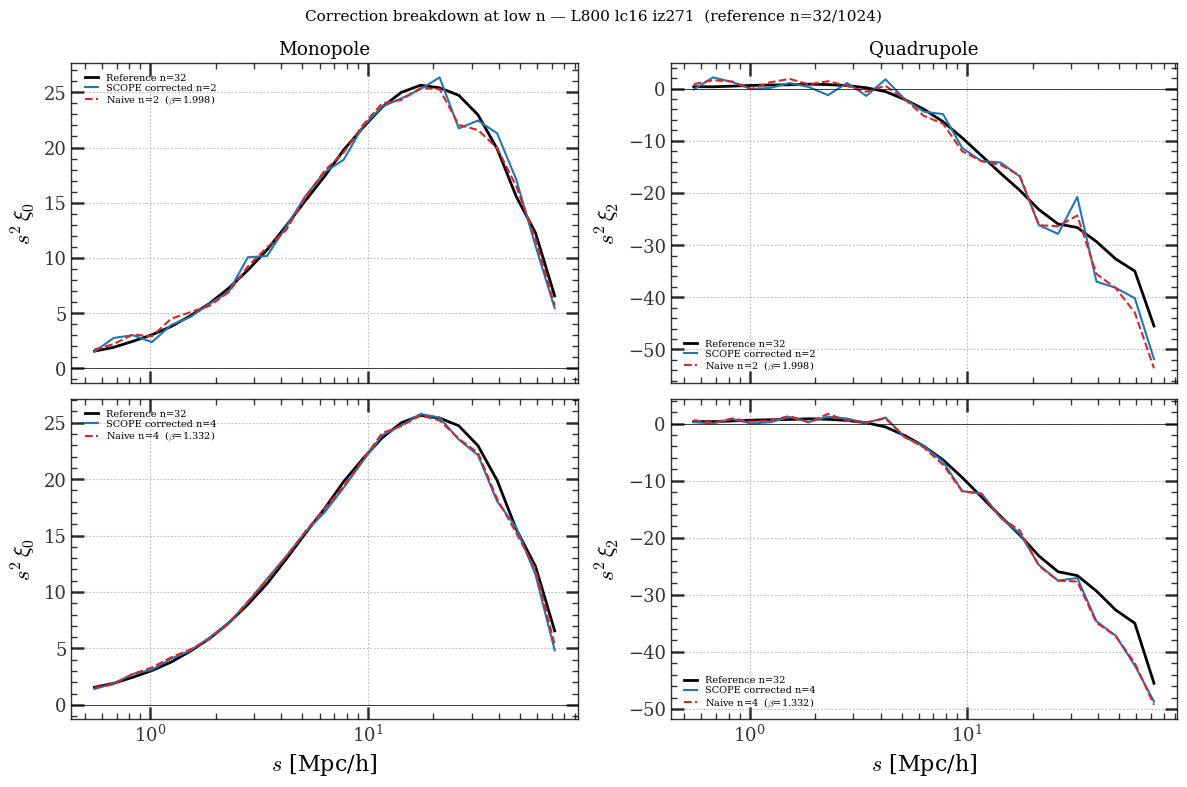

n=  2  alpha=0.0020  beta=1.9980  auto_frac=0.500
n=  4  alpha=0.0039  beta=1.3320  auto_frac=0.250
n= 32  alpha=0.0312  beta=1.0312  auto_frac=0.031


In [9]:
_dmu_d    = 1.0 / N_MU_BINS
_mu_mid_d = np.linspace(_dmu_d / 2.0, 1.0 - _dmu_d / 2.0, N_MU_BINS)
_L2_d     = 0.5 * (3.0 * _mu_mid_d**2 - 1.0)

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)

for row, n_demo in enumerate([2, 4]):
    mask   = subvol_ids < n_demo
    res_d  = scope.compute_xi_smu(
        coords_rsd[mask], subvol_ids[mask], S_BINS, BOXSIZE, K_TOTAL, n_demo,
        n_mu_bins=N_MU_BINS, mu_max=1.0,
    )
    alpha_d = n_demo / K_TOTAL
    beta_d  = n_demo * (K_TOTAL - 1) / (K_TOTAL * (n_demo - 1))

    # corrected (SCOPE)
    xi0_d = res_d["xi0"]
    xi2_d = res_d["xi2"]

    # naive: alpha=beta=1
    xi_smu_naive_d  = (res_d["dd_auto"] + res_d["dd_cross"]) / res_d["rr"] - 1.0
    xi0_naive_d     = np.nansum(xi_smu_naive_d * _dmu_d, axis=1)
    xi2_naive_d     = 5.0 * np.nansum(xi_smu_naive_d * _L2_d[np.newaxis, :] * _dmu_d, axis=1)

    for col, (xi_c, xi_n, xi_ref, ylabel) in enumerate([
        (xi0_d, xi0_naive_d, xi0, r"$s^2\,\xi_0$"),
        (xi2_d, xi2_naive_d, xi2, r"$s^2\,\xi_2$"),
    ]):
        ax = axes[row, col]
        ax.plot(s_mid, s_mid**2 * xi_ref,  "k-",  lw=2,   label=rf"Reference n={N_SUBVOLS}")
        ax.plot(s_mid, s_mid**2 * xi_c,    "C0-", lw=1.5, label=rf"SCOPE corrected n={n_demo}")
        ax.plot(s_mid, s_mid**2 * xi_n,    "C3--",lw=1.5,
                label=rf"Naive n={n_demo}  ($\beta$={beta_d:.3f})")
        ax.axhline(0, color="k", lw=0.5)
        ax.set_xscale("log")
        ax.set_ylabel(ylabel)
        ax.legend(fontsize=7)
        if row == 0:
            ax.set_title(["Monopole", "Quadrupole"][col])
        if row == 1:
            ax.set_xlabel(r"$s$ [Mpc/h]")

fig.suptitle(
    f"Correction breakdown at low n — L800 lc16 iz{IZ}  "
    f"(reference n={N_SUBVOLS}/{K_TOTAL})",
    fontsize=11,
)
fig.tight_layout()
out_dir = Path("_plots/scope_rsd_kaiser")
out_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(out_dir / f"correction_demo_low_n_iz{IZ}.png", dpi=150)
plt.show()

for n_demo in [2, 4, 32]:
    alpha_d = n_demo / K_TOTAL
    beta_d  = n_demo * (K_TOTAL - 1) / (K_TOTAL * (n_demo - 1))
    auto_frac = n_demo / (n_demo + n_demo*(n_demo-1))
    print(f"n={n_demo:3d}  alpha={alpha_d:.4f}  beta={beta_d:.4f}  auto_frac={auto_frac:.3f}")

## Kaiser model prediction

In [10]:
# Growth rate
omega_mz = om * (1.0 + z_snap)**3 / ez**2
f_z = omega_mz**0.55

# Interpolate ξ(r) onto fine grid for ξ̄(r) integration
# Extend to r=0 with ξ[0] (constant extrapolation inward)
r_fine  = np.linspace(0.0, r_mid[-1], 2000)
xi_interp = interp1d(r_mid, xi_r, kind="linear",
                     bounds_error=False, fill_value=(xi_r[0], 0.0))
xi_fine = xi_interp(r_fine)

# ξ̄(r) = 3/r³ ∫₀ʳ ξ(r') r'² dr'
integrand = xi_fine * r_fine**2
cum_int   = cumulative_trapezoid(integrand, r_fine, initial=0.0)
with np.errstate(divide="ignore", invalid="ignore"):
    xi_bar_fine = np.where(r_fine > 0, 3.0 / r_fine**3 * cum_int, xi_fine)

# Interpolate ξ̄ back onto s_mid
xi_bar_interp = interp1d(r_fine, xi_bar_fine, kind="linear",
                          bounds_error=False, fill_value=0.0)
xi_r_at_s    = xi_interp(s_mid)
xi_bar_at_s  = xi_bar_interp(s_mid)


def kaiser_multipoles(beta, xi_r_s, xi_bar_s):
    xi0_k = (1.0 + 2.0*beta/3.0 + beta**2/5.0) * xi_r_s
    xi2_k = (4.0*beta/3.0 + 4.0*beta**2/7.0) * (xi_r_s - xi_bar_s)
    return xi0_k, xi2_k


# Fit β on the specified scale range using both ξ₀ and ξ₂
mask = (s_mid >= FIT_SMIN) & (s_mid <= FIT_SMAX)

def chi2(beta):
    xi0_k, xi2_k = kaiser_multipoles(beta, xi_r_at_s[mask], xi_bar_at_s[mask])
    r0 = (xi0[mask] - xi0_k) / (np.abs(xi0[mask]) + 0.01)
    r2 = (xi2[mask] - xi2_k) / (np.abs(xi2[mask]) + 0.01)
    return np.sum(r0**2 + r2**2)

result  = minimize_scalar(chi2, bounds=(0.05, 2.0), method="bounded")
beta_fit = result.x
b_fit    = f_z / beta_fit

print(f"f(z)    = {f_z:.4f}")
print(f"β fit   = {beta_fit:.4f}")
print(f"b fit   = {b_fit:.4f}")

xi0_kaiser, xi2_kaiser = kaiser_multipoles(beta_fit, xi_r_at_s, xi_bar_at_s)

f(z)    = 0.5223
β fit   = 0.5758
b fit   = 0.9071


## Plots

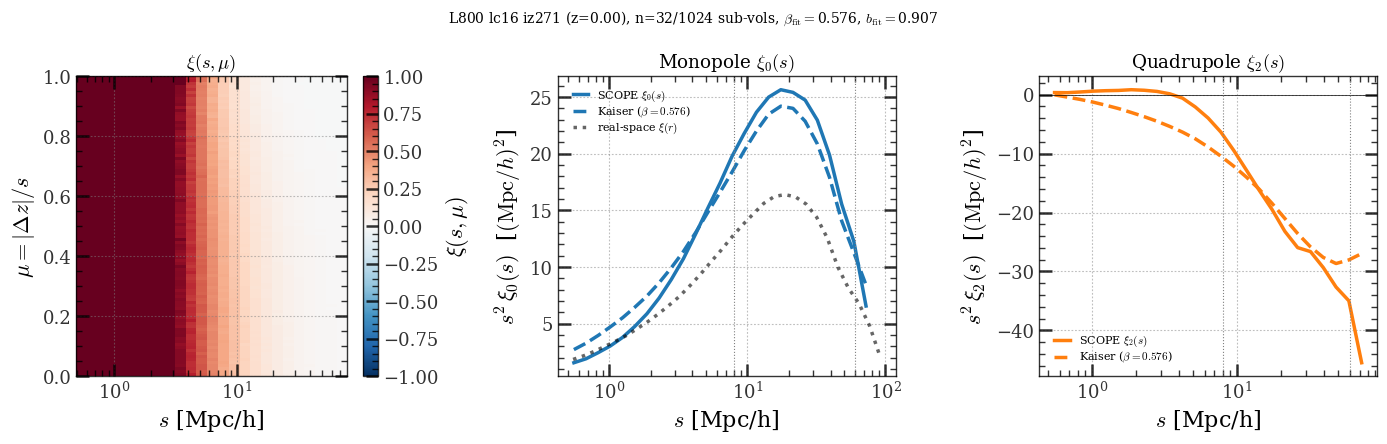

Saved to _plots/scope_rsd_kaiser


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

# ── Panel 1: ξ(s, μ) wedge map ──────────────────────────────────────────────
ax = axes[0]
vlim = 1.0
im = ax.pcolormesh(
    s_mid, mu_mid, xi_smu.T,
    vmin=-vlim, vmax=vlim, cmap="RdBu_r",
)
fig.colorbar(im, ax=ax, label=r"$\xi(s,\mu)$")
ax.set_xlabel(r"$s$ [Mpc/h]")
ax.set_ylabel(r"$\mu = |\Delta z|/s$")
ax.set_xscale("log")
ax.set_title(r"$\xi(s,\mu)$")

# ── Panel 2: monopole ξ₀(s) ──────────────────────────────────────────────────
ax = axes[1]
ax.plot(s_mid, s_mid**2 * xi0,        color="C0", label=r"SCOPE $\xi_0(s)$")
ax.plot(s_mid, s_mid**2 * xi0_kaiser, color="C0", ls="--", label=r"Kaiser ($\beta={:.3f}$)".format(beta_fit))
ax.plot(r_mid, r_mid**2 * xi_r,       color="k",  ls=":",  label=r"real-space $\xi(r)$", alpha=0.6)
ax.axvline(FIT_SMIN, color="gray", lw=0.8, ls=":")
ax.axvline(FIT_SMAX, color="gray", lw=0.8, ls=":")
ax.set_xscale("log")
ax.set_xlabel(r"$s$ [Mpc/h]")
ax.set_ylabel(r"$s^2\,\xi_0(s)$  [$(\mathrm{Mpc}/h)^2$]")
ax.set_title(r"Monopole $\xi_0(s)$")
ax.legend(fontsize=8)

# ── Panel 3: quadrupole ξ₂(s) ────────────────────────────────────────────────
ax = axes[2]
ax.plot(s_mid, s_mid**2 * xi2,        color="C1", label=r"SCOPE $\xi_2(s)$")
ax.plot(s_mid, s_mid**2 * xi2_kaiser, color="C1", ls="--", label=r"Kaiser ($\beta={:.3f}$)".format(beta_fit))
ax.axhline(0, color="k", lw=0.5)
ax.axvline(FIT_SMIN, color="gray", lw=0.8, ls=":")
ax.axvline(FIT_SMAX, color="gray", lw=0.8, ls=":")
ax.set_xscale("log")
ax.set_xlabel(r"$s$ [Mpc/h]")
ax.set_ylabel(r"$s^2\,\xi_2(s)$  [$(\mathrm{Mpc}/h)^2$]")
ax.set_title(r"Quadrupole $\xi_2(s)$")
ax.legend(fontsize=8)

fig.suptitle(
    f"L800 lc16 iz{IZ} (z={z_snap:.2f}), "
    f"n={N_SUBVOLS}/{K_TOTAL} sub-vols, "
    r"$\beta_\mathrm{fit}=$" + f"{beta_fit:.3f}, "
    r"$b_\mathrm{fit}=$" + f"{b_fit:.3f}",
    fontsize=10,
)
fig.tight_layout()

out_dir = Path("_plots/scope_rsd_kaiser")
out_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(out_dir / f"scope_rsd_kaiser_iz{IZ}_n{N_SUBVOLS}.png", dpi=150)
plt.show()
print("Saved to", out_dir)

## Kaiser boost

The Kaiser boost is the ratio of the redshift-space monopole to the real-space correlation function.
In linear theory this ratio is a **scale-independent constant**:

$$\frac{\xi_0(s)}{\xi(r)} = 1 + \frac{2\beta}{3} + \frac{\beta^2}{5}$$

**Left panel** — measured boost $\xi_0(s)/\xi(r)|_{r=s}$ vs scale.  
On large scales ($s \gtrsim 10\,\mathrm{Mpc}/h$) linear Kaiser theory holds and the ratio should plateau at the dashed line.  
On small scales FoG suppression pulls the ratio below the Kaiser level.

**Right panel** — quadrupole-to-monopole ratio $\xi_2(s)/\xi_0(s)$.  
This probes the anisotropy directly; in Kaiser theory it is scale-dependent because $\bar\xi(r)$ varies with $r$.

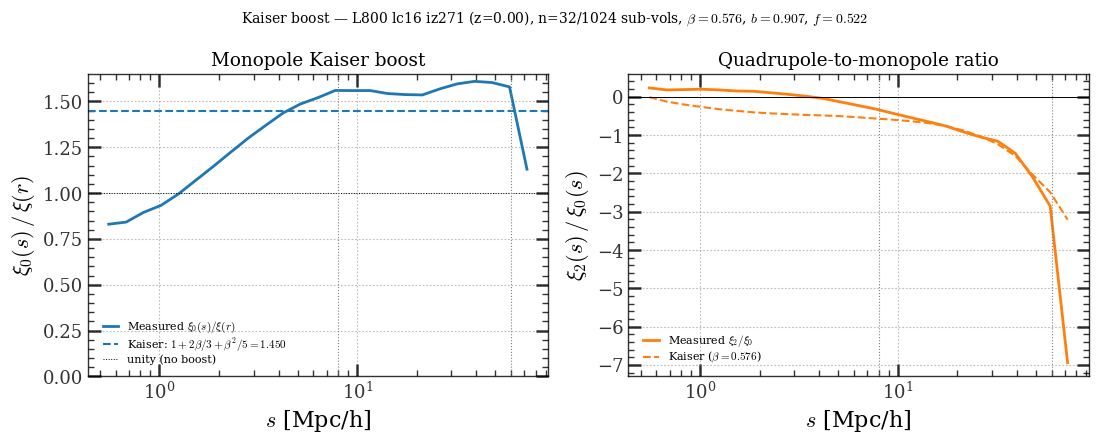

Kaiser boost level (1 + 2β/3 + β²/5) = 1.4502


In [12]:
kaiser_boost_level = 1.0 + 2.0*beta_fit/3.0 + beta_fit**2/5.0

# Mask out scales where ξ(r) crosses zero (ratio ill-defined)
xi_r_at_s_safe = xi_r_at_s.copy()
xi_r_at_s_safe[xi_r_at_s_safe <= 0] = np.nan
xi0_safe = xi0.copy()
xi0_safe[xi_r_at_s_safe <= 0] = np.nan

boost_measured = xi0_safe / xi_r_at_s_safe
boost_kaiser   = xi0_kaiser / xi_r_at_s_safe  # should equal kaiser_boost_level everywhere

# Quadrupole-to-monopole ratio: Kaiser prediction
xi0_kaiser_safe = xi0_kaiser.copy()
xi0_kaiser_safe[np.abs(xi0_kaiser_safe) < 1e-6] = np.nan
q2m_kaiser   = xi2_kaiser / xi0_kaiser_safe
xi0_safe2    = xi0.copy()
xi0_safe2[np.abs(xi0_safe2) < 1e-6] = np.nan
q2m_measured = xi2 / xi0_safe2

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# ── Left: monopole boost ξ₀(s)/ξ(r) ─────────────────────────────────────────
ax = axes[0]
ax.plot(s_mid, boost_measured, color="C0", lw=2, label=r"Measured $\xi_0(s)/\xi(r)$")
ax.axhline(kaiser_boost_level, color="C0", ls="--", lw=1.5,
           label=rf"Kaiser: $1 + 2\beta/3 + \beta^2/5 = {kaiser_boost_level:.3f}$")
ax.axhline(1.0, color="k", lw=0.7, ls=":", label="unity (no boost)")
ax.axvline(FIT_SMIN, color="gray", lw=0.8, ls=":")
ax.axvline(FIT_SMAX, color="gray", lw=0.8, ls=":")
ax.set_xscale("log")
ax.set_xlabel(r"$s$ [Mpc/h]")
ax.set_ylabel(r"$\xi_0(s)\,/\,\xi(r)$")
ax.set_title("Monopole Kaiser boost")
ax.set_ylim(bottom=0)
ax.legend(fontsize=8)

# ── Right: quadrupole-to-monopole ratio ξ₂/ξ₀ ────────────────────────────────
ax = axes[1]
ax.plot(s_mid, q2m_measured, color="C1", lw=2, label=r"Measured $\xi_2/\xi_0$")
ax.plot(s_mid, q2m_kaiser,   color="C1", ls="--", lw=1.5,
        label=rf"Kaiser ($\beta={beta_fit:.3f}$)")
ax.axhline(0, color="k", lw=0.7)
ax.axvline(FIT_SMIN, color="gray", lw=0.8, ls=":")
ax.axvline(FIT_SMAX, color="gray", lw=0.8, ls=":")
ax.set_xscale("log")
ax.set_xlabel(r"$s$ [Mpc/h]")
ax.set_ylabel(r"$\xi_2(s)\,/\,\xi_0(s)$")
ax.set_title("Quadrupole-to-monopole ratio")
ax.legend(fontsize=8)

fig.suptitle(
    f"Kaiser boost — L800 lc16 iz{IZ} (z={z_snap:.2f}), "
    f"n={N_SUBVOLS}/{K_TOTAL} sub-vols, "
    rf"$\beta={beta_fit:.3f}$, $b={b_fit:.3f}$, $f={f_z:.3f}$",
    fontsize=10,
)
fig.tight_layout()
out_dir = Path("_plots/scope_rsd_kaiser")
out_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(out_dir / f"kaiser_boost_iz{IZ}_n{N_SUBVOLS}.png", dpi=150)
plt.show()
print(f"Kaiser boost level (1 + 2β/3 + β²/5) = {kaiser_boost_level:.4f}")

## Kaiser boost vs redshift

Repeat the boost measurement across all three available snapshots: iz271 (z=0), iz207 (z≈0.50), iz155 (z≈1.50).

Two competing effects drive the evolution of the boost level `(1 + 2β/3 + β²/5)`:
- **f(z)** rises with redshift (faster growth rate in ΛCDM)  
- **b(z)** for a halo-selected sample also rises with redshift (halos of a fixed mass are rarer / more biased at high z)  

The net β = f/b — and hence the boost — can go up or down depending on which effect dominates for this sample.

Each snapshot is loaded and processed independently using the same N_SUBVOLS and MHALO_MIN as the cells above.

In [ ]:
SNAP_IZS = [155, 207, 271]
SNAP_COLORS = ["C2", "C1", "C0"]  # high-z → low-z

snap_results = {}

for iz_s in SNAP_IZS:
    print(f"\n── iz{iz_s} ──")
    z_s = get_snapshot_redshift(f"iz{iz_s}")
    ez_s = np.sqrt(om * (1.0 + z_s)**3 + ol)
    hz_s = 100.0 * h * ez_s
    f_s  = (om * (1.0 + z_s)**3 / ez_s**2)**0.55
    print(f"  z={z_s:.4f}  H(z)={hz_s:.1f} km/s/Mpc  f(z)={f_s:.4f}")

    # Draw the same N_SUBVOLS realisations (deterministic seed per snapshot)
    rng_s = np.random.default_rng(SEED + iz_s)
    ivols_s = sorted(rng_s.choice(list(range(K_TOTAL)), size=N_SUBVOLS, replace=False).tolist())

    real_chunks, rsd_chunks, sv_chunks = [], [], []
    iz_path_s = BASE_DIR / f"iz{iz_s}"
    for label, iv in enumerate(ivols_s):
        arr, _ = read_galaxy_arrays(
            iz_path_s, ivol=iv, mhalo_min=MHALO_MIN,
            fields=["vzgal"], include_positions=True,
        )
        x  = np.asarray(arr["x"],     dtype=np.float64)
        y  = np.asarray(arr["y"],     dtype=np.float64)
        z_ = np.asarray(arr["z"],     dtype=np.float64)
        vz = np.asarray(arr["vzgal"], dtype=np.float64)
        z_rsd_s = np.mod(z_ + (vz / hz_s) * h, BOXSIZE)
        sv = np.full(len(x), label, dtype=np.int32)
        real_chunks.append(np.column_stack([x, y, z_]))
        rsd_chunks.append(np.column_stack([x, y, z_rsd_s]))
        sv_chunks.append(sv)

    coords_r_s = np.vstack(real_chunks)
    coords_z_s = np.vstack(rsd_chunks)
    svids_s    = np.concatenate(sv_chunks)
    print(f"  Galaxies: {len(coords_r_s):,}")

    # Real-space ξ(r)
    res_xi_s = scope.compute_xi(coords_r_s, svids_s, R_BINS, BOXSIZE, K_TOTAL, N_SUBVOLS)
    r_mid_s  = res_xi_s["r_mid"]
    xi_r_s   = res_xi_s["xi"]

    # Redshift-space ξ₀, ξ₂
    res_smu_s = scope.compute_xi_smu(
        coords_z_s, svids_s, S_BINS, BOXSIZE, K_TOTAL, N_SUBVOLS,
        n_mu_bins=N_MU_BINS, mu_max=1.0,
    )
    s_mid_s = res_smu_s["s_mid"]
    xi0_s   = res_smu_s["xi0"]
    xi2_s   = res_smu_s["xi2"]

    # ξ̄(r) and Kaiser model
    r_fine_s = np.linspace(0.0, r_mid_s[-1], 2000)
    xi_int_s = interp1d(r_mid_s, xi_r_s, kind="linear",
                        bounds_error=False, fill_value=(xi_r_s[0], 0.0))
    xi_fine_s  = xi_int_s(r_fine_s)
    cum_int_s  = cumulative_trapezoid(xi_fine_s * r_fine_s**2, r_fine_s, initial=0.0)
    with np.errstate(divide="ignore", invalid="ignore"):
        xi_bar_fine_s = np.where(r_fine_s > 0, 3.0 / r_fine_s**3 * cum_int_s, xi_fine_s)
    xi_bar_int_s = interp1d(r_fine_s, xi_bar_fine_s, kind="linear",
                             bounds_error=False, fill_value=0.0)
    xi_r_at_s_s   = xi_int_s(s_mid_s)
    xi_bar_at_s_s = xi_bar_int_s(s_mid_s)

    # Fit β
    fit_mask_s = (s_mid_s >= FIT_SMIN) & (s_mid_s <= FIT_SMAX)
    def chi2_s(beta):
        xi0_k = (1 + 2*beta/3 + beta**2/5) * xi_r_at_s_s[fit_mask_s]
        xi2_k = (4*beta/3 + 4*beta**2/7) * (xi_r_at_s_s[fit_mask_s] - xi_bar_at_s_s[fit_mask_s])
        r0 = (xi0_s[fit_mask_s] - xi0_k) / (np.abs(xi0_s[fit_mask_s]) + 0.01)
        r2 = (xi2_s[fit_mask_s] - xi2_k) / (np.abs(xi2_s[fit_mask_s]) + 0.01)
        return np.sum(r0**2 + r2**2)

    beta_fit_s = minimize_scalar(chi2_s, bounds=(0.05, 2.0), method="bounded").x
    b_fit_s    = f_s / beta_fit_s
    boost_s    = 1.0 + 2*beta_fit_s/3 + beta_fit_s**2/5

    # Kaiser multipoles
    xi0_k_s = boost_s * xi_r_at_s_s
    xi2_k_s = (4*beta_fit_s/3 + 4*beta_fit_s**2/7) * (xi_r_at_s_s - xi_bar_at_s_s)

    # Boost ratio (mask zero-crossings)
    xi_r_safe = xi_r_at_s_s.copy(); xi_r_safe[xi_r_safe <= 0] = np.nan
    xi0_safe  = xi0_s.copy();       xi0_safe[xi_r_at_s_s <= 0] = np.nan

    # q2m ratio
    xi0_q_safe = xi0_s.copy(); xi0_q_safe[np.abs(xi0_q_safe) < 1e-6] = np.nan
    xi0_k_safe = xi0_k_s.copy(); xi0_k_safe[np.abs(xi0_k_safe) < 1e-6] = np.nan

    snap_results[iz_s] = dict(
        z=z_s, f=f_s, b=b_fit_s, beta=beta_fit_s, boost_level=boost_s,
        s_mid=s_mid_s, r_mid=r_mid_s, xi_r=xi_r_s,
        xi0=xi0_s, xi2=xi2_s, xi0_k=xi0_k_s, xi2_k=xi2_k_s,
        boost_measured=xi0_safe / xi_r_safe,
        q2m_measured=xi2_s / xi0_q_safe,
        q2m_kaiser=xi2_k_s / xi0_k_safe,
    )
    print(f"  β={beta_fit_s:.4f}  b={b_fit_s:.4f}  boost={boost_s:.4f}")

print("\nDone.")

## β sweep: Kaiser predictions for a range of β values

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

ax0, ax1, ax2 = axes

for iz_s, col in zip(SNAP_IZS, SNAP_COLORS):
    r = snap_results[iz_s]
    label_str = rf"iz{iz_s}  $z={r['z']:.2f}$,  $\beta={r['beta']:.3f}$,  $b={r['b']:.3f}$"

    # Panel 1: s²ξ₀(s)
    ax0.plot(r["s_mid"], r["s_mid"]**2 * r["xi0"],  color=col, lw=2,    label=label_str)
    ax0.plot(r["s_mid"], r["s_mid"]**2 * r["xi0_k"], color=col, lw=1.2, ls="--")

    # Panel 2: monopole boost ξ₀(s)/ξ(r)
    ax1.plot(r["s_mid"], r["boost_measured"], color=col, lw=2, label=label_str)
    ax1.axhline(r["boost_level"], color=col, lw=1.0, ls="--",
                label=rf"Kaiser = {r['boost_level']:.3f}")

    # Panel 3: quadrupole-to-monopole ξ₂/ξ₀
    ax2.plot(r["s_mid"], r["q2m_measured"], color=col, lw=2, label=label_str)
    ax2.plot(r["s_mid"], r["q2m_kaiser"],   color=col, lw=1.2, ls="--")

# Panel 1
ax0.axhline(0, color="k", lw=0.5)
ax0.set_xscale("log")
ax0.set_xlabel(r"$s$ [Mpc/h]")
ax0.set_ylabel(r"$s^2\,\xi_0(s)$  [$(\mathrm{Mpc}/h)^2$]")
ax0.set_title(r"Monopole $\xi_0(s)$")
ax0.legend(fontsize=7)

# Panel 2
ax1.axhline(1.0, color="k", lw=0.7, ls=":", label="unity")
ax1.axvline(FIT_SMIN, color="gray", lw=0.7, ls=":")
ax1.axvline(FIT_SMAX, color="gray", lw=0.7, ls=":")
ax1.set_xscale("log")
ax1.set_xlabel(r"$s$ [Mpc/h]")
ax1.set_ylabel(r"$\xi_0(s)\,/\,\xi(r)$")
ax1.set_title("Kaiser boost  (solid=measured, dashed=Kaiser level)")
ax1.set_ylim(bottom=0)
ax1.legend(fontsize=7)

# Panel 3
ax2.axhline(0, color="k", lw=0.5)
ax2.axvline(FIT_SMIN, color="gray", lw=0.7, ls=":")
ax2.axvline(FIT_SMAX, color="gray", lw=0.7, ls=":")
ax2.set_xscale("log")
ax2.set_xlabel(r"$s$ [Mpc/h]")
ax2.set_ylabel(r"$\xi_2(s)\,/\,\xi_0(s)$")
ax2.set_title(r"$\xi_2/\xi_0$  (solid=measured, dashed=Kaiser)")
ax2.legend(fontsize=7)

fig.suptitle(
    f"Kaiser boost vs redshift — L800 lc16, "
    f"n={N_SUBVOLS}/{K_TOTAL} sub-vols, "
    rf"$M_\mathrm{{halo}} > 10^{{{np.log10(MHALO_MIN):.0f}}}\ M_\odot/h$",
    fontsize=10,
)
fig.tight_layout()
out_dir = Path("_plots/scope_rsd_kaiser")
out_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(out_dir / f"kaiser_boost_vs_redshift_n{N_SUBVOLS}.png", dpi=150)
plt.show()

# Summary table
print(f"{'iz':>6} {'z':>7} {'f(z)':>7} {'β':>7} {'b':>7} {'boost':>7}")
print("-" * 46)
for iz_s in SNAP_IZS:
    r = snap_results[iz_s]
    print(f"iz{iz_s:>3d}  {r['z']:>6.4f}  {r['f']:>6.4f}  {r['beta']:>6.4f}  {r['b']:>6.4f}  {r['boost_level']:>6.4f}")

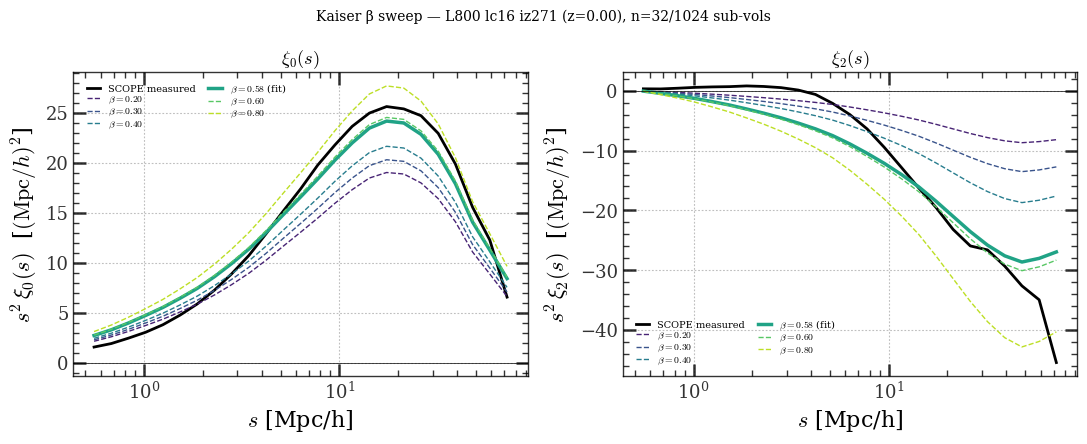

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
betas = [0.2, 0.3, 0.4, beta_fit, 0.6, 0.8]
cmap  = plt.cm.viridis
colors = cmap(np.linspace(0.1, 0.9, len(betas)))

for ax, (xi_meas, xi_k_func, label) in zip(
    axes,
    [
        (xi0, lambda b: kaiser_multipoles(b, xi_r_at_s, xi_bar_at_s)[0], r"$\xi_0(s)$"),
        (xi2, lambda b: kaiser_multipoles(b, xi_r_at_s, xi_bar_at_s)[1], r"$\xi_2(s)$"),
    ],
):
    ax.plot(s_mid, s_mid**2 * xi_meas, "k-", lw=2, label="SCOPE measured")
    for beta_i, col in zip(betas, colors):
        lw  = 2.5 if np.isclose(beta_i, beta_fit) else 1.0
        ls  = "-" if np.isclose(beta_i, beta_fit) else "--"
        lab = rf"$\beta={beta_i:.2f}$" + (" (fit)" if np.isclose(beta_i, beta_fit) else "")
        ax.plot(s_mid, s_mid**2 * xi_k_func(beta_i), color=col, lw=lw, ls=ls, label=lab)
    ax.axhline(0, color="k", lw=0.5)
    ax.set_xscale("log")
    ax.set_xlabel(r"$s$ [Mpc/h]")
    ax.set_ylabel(rf"$s^2\,{label.strip('$')}$  [$(\mathrm{{Mpc}}/h)^2$]")
    ax.set_title(label)
    ax.legend(fontsize=7, ncol=2)

fig.suptitle(
    f"Kaiser β sweep — L800 lc16 iz{IZ} (z={z_snap:.2f}), "
    f"n={N_SUBVOLS}/{K_TOTAL} sub-vols",
    fontsize=10,
)
fig.tight_layout()
fig.savefig(out_dir / f"scope_rsd_kaiser_bsweep_iz{IZ}_n{N_SUBVOLS}.png", dpi=150)
plt.show()

## Convergence: corrected vs naive estimator

We subset the already-loaded realisations to sweep over n values smaller than N_SUBVOLS, computing both the corrected (α/β-weighted) and naive (α=β=1) estimators.  The corrected curves should converge to the n=N_SUBVOLS reference; the naive curves should remain badly biased at low n.

**Why the naive estimator fails:** it counts DD correctly for the selected catalogue but the α/β weights are not applied, so one-halo (auto) and two-halo (cross) pair contributions carry the wrong relative normalisations relative to RR.

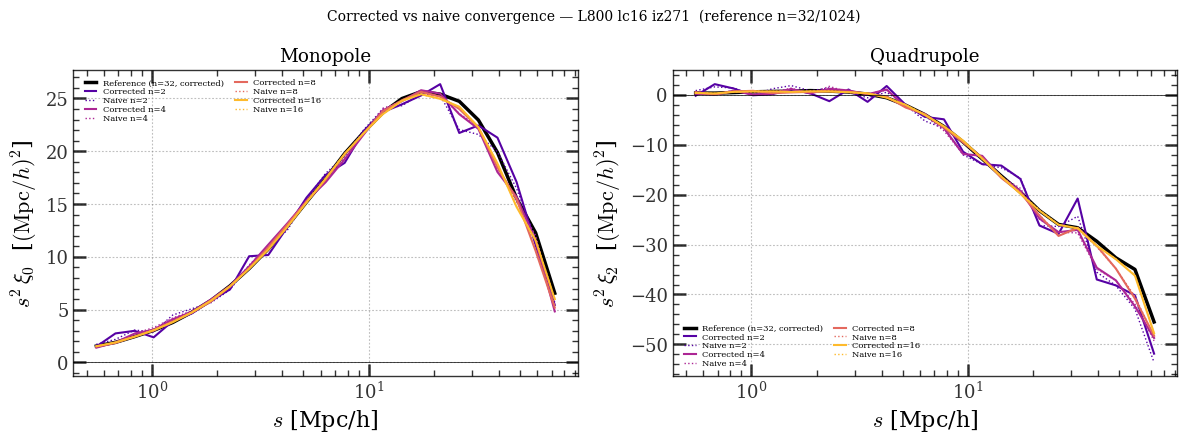

In [14]:
CONV_N_VALUES = [2, 4, 8, 16]  # must all be < N_SUBVOLS

_dmu    = 1.0 / N_MU_BINS
_mu_mid = np.linspace(_dmu / 2.0, 1.0 - _dmu / 2.0, N_MU_BINS)
_L2     = 0.5 * (3.0 * _mu_mid**2 - 1.0)

xi0_conv_corr, xi2_conv_corr   = {}, {}
xi0_conv_naive, xi2_conv_naive = {}, {}

for n in CONV_N_VALUES:
    mask = subvol_ids < n
    res  = scope.compute_xi_smu(
        coords_rsd[mask], subvol_ids[mask], S_BINS, BOXSIZE, K_TOTAL, n,
        n_mu_bins=N_MU_BINS, mu_max=1.0,
    )
    xi0_conv_corr[n]  = res["xi0"]
    xi2_conv_corr[n]  = res["xi2"]

    # Naive: alpha=beta=1 — no subvolume correction
    xi_naive_smu        = (res["dd_auto"] + res["dd_cross"]) / res["rr"] - 1.0
    xi0_conv_naive[n]   = np.nansum(xi_naive_smu * _dmu, axis=1)
    xi2_conv_naive[n]   = 5.0 * np.nansum(xi_naive_smu * _L2[np.newaxis, :] * _dmu, axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
colors_conv = plt.cm.plasma(np.linspace(0.15, 0.85, len(CONV_N_VALUES)))

for ax, xi_ref, corr_d, naive_d, ylabel, title in zip(
    axes,
    [xi0, xi2],
    [xi0_conv_corr, xi2_conv_corr],
    [xi0_conv_naive, xi2_conv_naive],
    [r"$s^2\,\xi_0$  [$(\mathrm{Mpc}/h)^2$]",
     r"$s^2\,\xi_2$  [$(\mathrm{Mpc}/h)^2$]"],
    ["Monopole", "Quadrupole"],
):
    ax.plot(s_mid, s_mid**2 * xi_ref, "k-", lw=2.5,
            label=rf"Reference (n={N_SUBVOLS}, corrected)")
    for col, n in zip(colors_conv, CONV_N_VALUES):
        ax.plot(s_mid, s_mid**2 * corr_d[n],  color=col, lw=1.5, ls="-",
                label=rf"Corrected n={n}")
        ax.plot(s_mid, s_mid**2 * naive_d[n], color=col, lw=1.0, ls=":",
                label=rf"Naive n={n}")
    ax.axhline(0, color="k", lw=0.5)
    ax.set_xscale("log")
    ax.set_xlabel(r"$s$ [Mpc/h]")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(fontsize=6, ncol=2)

fig.suptitle(
    f"Corrected vs naive convergence — L800 lc16 iz{IZ}  "
    f"(reference n={N_SUBVOLS}/{K_TOTAL})",
    fontsize=10,
)
fig.tight_layout()
out_dir = Path("_plots/scope_rsd_kaiser")
out_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(out_dir / f"convergence_corr_vs_naive_iz{IZ}.png", dpi=150)
plt.show()

## Seed test: corrected estimator is unbiased

At a fixed n we draw N_SEED_RUNS independent random subsets of size n from the loaded realisations.  Each draw gives a different estimate; the key question is whether the **mean** over draws is consistent with the reference, not just whether individual draws scatter around it.

An unbiased estimator satisfies ⟨ξ̂⟩ = ξ_true at any n — the scatter shrinks as n grows, but the centre should not shift.

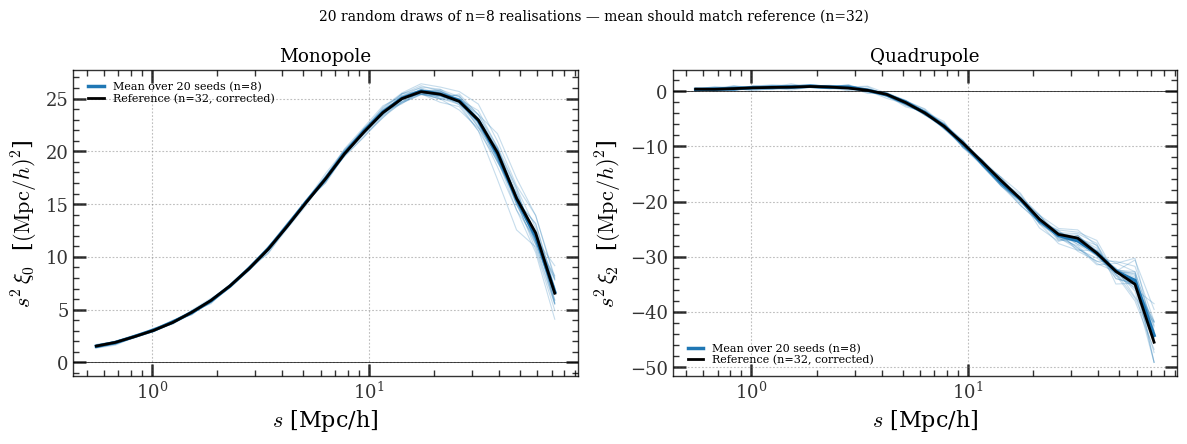

In [15]:
N_SEED_TEST = 8    # realisations per draw
N_SEED_RUNS = 20   # number of independent random subsets

rng_seed_test = np.random.default_rng(999)
all_labels    = np.arange(N_SUBVOLS)

xi0_seed_runs, xi2_seed_runs = [], []

for _ in range(N_SEED_RUNS):
    chosen   = rng_seed_test.choice(all_labels, size=N_SEED_TEST, replace=False)
    mask     = np.isin(subvol_ids, chosen)
    sv_orig  = subvol_ids[mask]
    sv_remap = np.empty(mask.sum(), dtype=np.int32)
    for new_id, old_id in enumerate(chosen):
        sv_remap[sv_orig == old_id] = new_id

    res = scope.compute_xi_smu(
        coords_rsd[mask], sv_remap, S_BINS, BOXSIZE, K_TOTAL, N_SEED_TEST,
        n_mu_bins=N_MU_BINS, mu_max=1.0,
    )
    xi0_seed_runs.append(res["xi0"])
    xi2_seed_runs.append(res["xi2"])

xi0_seed_runs = np.array(xi0_seed_runs)
xi2_seed_runs = np.array(xi2_seed_runs)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, xi_runs, xi_ref, ylabel, title in zip(
    axes,
    [xi0_seed_runs, xi2_seed_runs],
    [xi0, xi2],
    [r"$s^2\,\xi_0$  [$(\mathrm{Mpc}/h)^2$]",
     r"$s^2\,\xi_2$  [$(\mathrm{Mpc}/h)^2$]"],
    ["Monopole", "Quadrupole"],
):
    for curve in xi_runs:
        ax.plot(s_mid, s_mid**2 * curve, color="C0", alpha=0.25, lw=0.8)
    ax.plot(s_mid, s_mid**2 * xi_runs.mean(axis=0), color="C0", lw=2.5,
            label=rf"Mean over {N_SEED_RUNS} seeds (n={N_SEED_TEST})")
    ax.plot(s_mid, s_mid**2 * xi_ref, "k-", lw=2,
            label=rf"Reference (n={N_SUBVOLS}, corrected)")
    ax.axhline(0, color="k", lw=0.5)
    ax.set_xscale("log")
    ax.set_xlabel(r"$s$ [Mpc/h]")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(fontsize=8)

fig.suptitle(
    f"{N_SEED_RUNS} random draws of n={N_SEED_TEST} realisations — "
    f"mean should match reference (n={N_SUBVOLS})",
    fontsize=10,
)
fig.tight_layout()
out_dir = Path("_plots/scope_rsd_kaiser")
out_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(out_dir / f"seed_test_iz{IZ}_n{N_SEED_TEST}.png", dpi=150)
plt.show()

## Summary

In [16]:
print("="*55)
print(f"  Snapshot    : iz{IZ}  (z = {z_snap:.4f})")
print(f"  Sub-volumes : {N_SUBVOLS} / {K_TOTAL}")
print(f"  Galaxies    : {len(coords_real):,}")
print(f"  Mhalo min   : {MHALO_MIN:.0e} M_sun/h")
print()
print(f"  f(z)        : {f_z:.4f}")
print(f"  β fit       : {beta_fit:.4f}")
print(f"  b fit       : {b_fit:.4f}")
print(f"  f/b = β     : {f_z/b_fit:.4f} (consistency check)")
print("="*55)

  Snapshot    : iz271  (z = 0.0000)
  Sub-volumes : 32 / 1024
  Galaxies    : 1,034,900
  Mhalo min   : 1e+10 M_sun/h

  f(z)        : 0.5223
  β fit       : 0.5758
  b fit       : 0.9071
  f/b = β     : 0.5758 (consistency check)
